In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ieee-fraud-detection/sample_submission.csv
/kaggle/input/ieee-fraud-detection/test_identity.csv
/kaggle/input/ieee-fraud-detection/train_identity.csv
/kaggle/input/ieee-fraud-detection/test_transaction.csv
/kaggle/input/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install mlflow dagshub --quiet
import mlflow
from dagshub import dagshub_logger
import os

# Set tracking URI manually
mlflow.set_tracking_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

# Use your DagsHub credentials
os.environ["MLFLOW_TRACKING_USERNAME"] = "ekvirika"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "3f601f2c2c7a6bca448ebc69f4f5d4b49daffd8f"

# Optional: set registry if you're using model registry
mlflow.set_registry_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 44.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 78.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. Th

In [3]:
"""Main function to run the entire pipeline with enhanced feature engineering"""
print("Starting IEEE-CIS Fraud Detection Pipeline with Magic Features")

# Define data paths - update these to your actual file paths
transaction_path = "/kaggle/input/ieee-fraud-detection/train_transaction.csv"  # Update this path
identity_path = "/kaggle/input/ieee-fraud-detection/train_identity.csv"  # Update this path


Starting IEEE-CIS Fraud Detection Pipeline with Magic Features


In [4]:
df = pd.read_csv(transaction_path)
id_df = pd.read_csv(identity_path)

In [5]:
mlflow.set_experiment('DecisionTree_Training')

<Experiment: artifact_location='mlflow-artifacts:/90ac70d8239143c0a00a690e758ad6db', creation_time=1745761114156, experiment_id='6', last_update_time=1745761114156, lifecycle_stage='active', name='DecisionTree_Training', tags={}>

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import datetime
from datetime import timedelta

# ML models
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# For handling imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Feature Engineering and Feature selection pipeline classes

In [6]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# --- Custom Transformers ---

class TimeFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.start_date = pd.to_datetime('2017-12-01')
        self.label_encoders = {}

    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.tolist()
        categorical_cols = X.select_dtypes(include=['object', 'category']).columns
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.label_encoders[col] = le
        return self

    def transform(self, X):

        if 'TransactionDT' in X.columns:
            X['Transaction_hour'] = ((X['TransactionDT']// (60*60)) % 24).astype('int8')
            X['Transaction_day'] = ((X['TransactionDT']// (24*60*60)).astype('int16'))
            X['Transaction_weekday'] = X['Transaction_day'] % 7
            # X['Transaction_month'] = X['TransactionDT'].dt.month
            # X['Transaction_year'] = X['TransactionDT'].dt.year

        for col, le in self.label_encoders.items():
            X[col] = le.transform(X[col].astype(str))

        return X

class NumericalFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, numerical_columns=None):
        self.numerical_columns = numerical_columns

    def fit(self, X, y=None):
        if self.numerical_columns is None:
            self.numerical_columns = X.select_dtypes(include=[np.number]).columns.tolist()
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.numerical_columns)
        return X[self.numerical_columns].copy()

class NanPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='mean'):
        self.strategy = strategy
        self.fill_values = {}

    def fit(self, X, y=None):
        for col in X.columns:
            if self.strategy == 'mean':
                self.fill_values[col] = X[col].mean()
            elif self.strategy == 'median':
                self.fill_values[col] = X[col].median()
            elif self.strategy == 'mode':
                self.fill_values[col] = X[col].mode()[0]
            else:
                raise ValueError(f"Unknown strategy: {self.strategy}")
        return self

    def transform(self, X):
        X = X.copy()
        for col, fill_value in self.fill_values.items():
            X[col] = X[col].fillna(fill_value)
        return X

class UserIDCreator(BaseEstimator, TransformerMixin):
    def __init__(self, version=1):
        self.version = version

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if self.version == 1:
            X['user_id'] = X['card1'].astype(str) + '_' + \
                           X['Transaction_day'].astype(str) + '_' + \
                           X['Transaction_hour'].astype(str)
        else:
            X['user_id'] = X['card1'].astype(str) + '_' + \
                           X['P_emaildomain'].astype(str) + '_' + \
                           X['Transaction_day'].astype(str)
        return X

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[f'{col}_freq_enc'] = X[col].map(self.freq_maps[col])
        return X

class WOEEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns, target_col):
        self.columns = columns
        self.target_col = target_col
        self.woe_maps = {}

    def fit(self, X, y=None):
        eps = 1e-6
        for col in self.columns:
            temp = X.groupby(col)[self.target_col].agg(['sum', 'count'])
            temp['good'] = temp['count'] - temp['sum']
            temp['bad_rate'] = (temp['sum'] + eps) / (temp['count'] + eps)
            temp['good_rate'] = (temp['good'] + eps) / (temp['count'] + eps)
            temp['woe'] = np.log(temp['good_rate'] / temp['bad_rate'])
            self.woe_maps[col] = temp['woe'].to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[f'{col}_woe_enc'] = X[col].map(self.woe_maps[col])
        return X

class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns, target_col):
        self.columns = columns
        self.target_col = target_col
        self.target_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.target_maps[col] = X.groupby(col)[self.target_col].mean()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[f'{col}_target_enc'] = X[col].map(self.target_maps[col])
        return X




## Custom user_time split

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
    
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def custom_user_time_split(X, y, user_col='user_id', time_col='TransactionDT', test_size=0.2, random_state=42):
    # 1. Create a copy to avoid messing up
    X_ = X.copy()
    y_ = y.copy()

    # 2. Group by user_id: get min timestamp per user
    user_min_time = X_.groupby(user_col)[time_col].min()

    # 3. Sort users by their first transaction
    user_min_time = user_min_time.sort_values()

    # 4. Create train/test user splits based on first transaction time
    n_users = len(user_min_time)
    n_test_users = int(test_size * n_users)

    np.random.seed(random_state)
    test_users = user_min_time.index[-n_test_users:]  # latest users for test
    train_users = user_min_time.index[:-n_test_users]

    # 5. Split X and y based on user_id
    X_train = X_[X_[user_col].isin(train_users)].reset_index(drop=True)
    X_test = X_[X_[user_col].isin(test_users)].reset_index(drop=True)
    y_train = y_[X_[user_col].isin(train_users)].reset_index(drop=True)
    y_test = y_[X_[user_col].isin(test_users)].reset_index(drop=True)

    print(f"✅ Split done! Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test



In [28]:
X_train.shape

(590540, 404)

In [29]:
X_test.shape

(0, 404)

In [ ]:
folder_path = '/kaggle/input/ieee-fraud-detection/'

# Load training data
print("Loading datasets...")
train_identity = pd.read_csv(f'{folder_path}train_identity.csv')
train_transaction = pd.read_csv(f'{folder_path}train_transaction.csv')

# Merge the training data
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
del train_identity, train_transaction

# Check class imbalance
fraud_count = train['isFraud'].value_counts()
print(f"Class distribution before SMOTE:\n{fraud_count}")
print(f"Fraud rate: {fraud_count[1] / (fraud_count[0] + fraud_count[1]) * 100:.2f}%")

# Feature Engineering

# Feature Engineering

In [ ]:
def FeaturePipeline():
    pipeline = Pipeline([
        ('time_features', TimeFeatureExtractor()),
        ('nan_preprocessing', NanPreprocessor(strategy='mean')),  # 🤓 Smart NaN fix
        ('numerical_features', NumericalFeatureExtractor()),
        ('user_id', UserIDCreator(version=1)),
        ('freq_encoding', FrequencyEncoder(columns=['card1', 'P_emaildomain'])),
        ('woe_encoding', WOEEncoder(columns=['card1', 'P_emaildomain'], target_col='isFraud')),
        ('target_encoding', TargetEncoder(columns=['card1', 'P_emaildomain'], target_col='isFraud')),
    ])
    return pipeline

In [ ]:
class DropNA(BaseEstimator, TransformerMixin):
    """
    Drops columns based on null threshold and value dominance
    """
    def __init__(self, null_threshold=0.9, value_dominance_threshold=0.9):
        self.null_threshold = null_threshold
        self.value_dominance_threshold = value_dominance_threshold
        self.cols_to_drop_ = None
    
    def fit(self, X, y=None):
        many_null_cols = self._get_null_columns(X)
        big_top_value_cols = self._get_dominant_value_columns(X)
        one_value_cols = self._get_single_value_columns(X)
        
        self.cols_to_drop_ = list(set(many_null_cols + big_top_value_cols + one_value_cols))
        
        self.cols_to_drop_ = [col for col in self.cols_to_drop_ if col != 'isFraud']
        
        return self
    
    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, axis=1, errors='ignore')
    
    def _get_null_columns(self, df):
        return [col for col in df.columns 
                if df[col].isnull().sum() / len(df) > self.null_threshold]
    
    def _get_dominant_value_columns(self, df):
        dominant_cols = []
        for col in df.columns:
            value_counts = df[col].value_counts(dropna=False, normalize=True)
            if len(value_counts) > 0 and value_counts.iloc[0] > self.value_dominance_threshold:
                dominant_cols.append(col)
        return dominant_cols
    
    def _get_single_value_columns(self, df):
        return [col for col in df.columns if df[col].nunique(dropna=False) == 1]

class MissingValueImputer(BaseEstimator, TransformerMixin):
    """
    Imputes missing values for categorical and numerical columns
    """
    def __init__(self, cat_fill_value="Unknown", num_strategy="median"):
        self.cat_fill_value = cat_fill_value
        self.num_strategy = num_strategy
        self.num_fill_values_ = {}
        self.categorical_columns_ = None
        self.numerical_columns_ = None
    
    def fit(self, X, y=None):
        self.categorical_columns_ = X.select_dtypes(include=['object', 'category']).columns.tolist()
        self.numerical_columns_ = X.select_dtypes(include=['number']).columns.tolist()
        
        if self.num_strategy == "median":
            for col in self.numerical_columns_:
                self.num_fill_values_[col] = X[col].median()
        
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        for col in self.categorical_columns_:
            X_transformed[col] = X_transformed[col].fillna(self.cat_fill_value)
        
        for col in self.numerical_columns_:
            X_transformed[col] = X_transformed[col].fillna(self.num_fill_values_[col])
        
        return X_transformed

class CatEncoding(BaseEstimator, TransformerMixin):
    """
    Encodes categorical variables using Weight of Evidence
    """
    def __init__(self, threshold=3):
        self.threshold = threshold
    
    def fit(self, X, y):
        cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        s = X[cat_cols].nunique()
        self.woe_columns = s[s > self.threshold].index.tolist()
        self.one_hot_columns = s[s <= self.threshold].index.tolist()
        
        # Store most frequent category to handle missing values
        self.woe_columns_fill_na = X[self.woe_columns].mode().iloc[0].to_dict()
        
        woe_mappings = {}
        iv_values = {}
        df = X.copy()
        df['_target_'] = y
        
        for col in self.woe_columns:
            groups = df.groupby(col, dropna=False)['_target_'].agg(['count', 'sum'])
            groups.columns = ['n_obs', 'n_pos']
            groups['n_neg'] = groups['n_obs'] - groups['n_pos']
            groups['prop_pos'] = groups['n_pos'] / max(groups['n_pos'].sum(), 1e-6)
            groups['prop_neg'] = groups['n_neg'] / max(groups['n_neg'].sum(), 1e-6)
            groups['woe'] = np.log((groups['prop_pos'] + 1e-6) / (groups['prop_neg'] + 1e-6))
            groups['iv'] = (groups['prop_pos'] - groups['prop_neg']) * groups['woe']
            groups = groups.replace([np.inf, -np.inf], 0).fillna(0)
            woe_mappings[col] = groups['woe'].to_dict()
            iv_values[col] = groups['iv'].sum()
            
        self.woe_mappings = woe_mappings
        self.iv_values = iv_values
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        for col in self.woe_columns:
            mapping = self.woe_mappings[col]
            default_value = mapping.get(self.woe_columns_fill_na[col], 0)
            
            # Transform column and handle unseen values
            transformed_col = X_transformed[col].map(lambda x: mapping.get(x, default_value))
            X_transformed[f'woe_{col}'] = transformed_col
            X_transformed.drop(columns=col, inplace=True)
        
        # One-hot encode remaining columns
        if self.one_hot_columns:
            X_transformed = pd.get_dummies(
                X_transformed,
                columns=self.one_hot_columns,
                drop_first=True,
                dummy_na=True,
                dtype=int
            )
        
        # Final check for NaNs
        if X_transformed.isnull().any().any():
            nan_cols = X_transformed.columns[X_transformed.isnull().any()].tolist()
            raise ValueError(f"Unexpected NaNs found in columns: {nan_cols}")
            
        return X_transformed

class NumericalProcessor(BaseEstimator, TransformerMixin):
    """
    Identifies outliers in numerical columns using modified Z-score
    """
    def __init__(self, z_threshold=3.5):
        self.z_threshold = z_threshold
        self.medians_ = {}
        self.mads_ = {}

    def fit(self, X, y=None):
        print('NumericalProcessor fitting...')
        num_cols = X.select_dtypes(include=np.number).columns
        self.medians_ = {col: X[col].median() for col in num_cols}
        self.mads_ = {col: np.median(np.abs(X[col] - self.medians_[col])) + 1e-10 for col in num_cols}
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.medians_:
            med = self.medians_[col]
            mad = self.mads_[col]
            modified_z = 0.6745 * (X[col] - med) / mad  # Modified Z-score
            X[f'{col}_outlier'] = (np.abs(modified_z) > self.z_threshold).astype(int)
        return X

class TimeFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extracts time-related features from TransactionDT
    """
    def __init__(self, start_date='2017-12-01'):
        self.start_date = datetime.datetime.strptime(start_date, '%Y-%m-%d')
    
    def fit(self, X, y=None):
        print('TimeFeatureExtractor fitting...')
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        # Convert TransactionDT to datetime
        X_transformed['datetime'] = X_transformed['TransactionDT'].apply(
            lambda x: self.start_date + timedelta(seconds=x)
        )
        
        # Extract time features
        X_transformed['hour'] = X_transformed['datetime'].dt.hour
        X_transformed['day'] = X_transformed['datetime'].dt.day
        X_transformed['weekday'] = X_transformed['datetime'].dt.weekday
        X_transformed['month'] = X_transformed['datetime'].dt.month
        X_transformed['year'] = X_transformed['datetime'].dt.year
        
        # Time periods
        X_transformed['is_weekend'] = X_transformed['weekday'].apply(lambda x: 1 if x >= 5 else 0)
        X_transformed['is_night'] = X_transformed['hour'].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)
        X_transformed['is_morning'] = X_transformed['hour'].apply(lambda x: 1 if (6 <= x <= 11) else 0)
        X_transformed['is_afternoon'] = X_transformed['hour'].apply(lambda x: 1 if (12 <= x <= 17) else 0)
        X_transformed['is_evening'] = X_transformed['hour'].apply(lambda x: 1 if (18 <= x <= 21) else 0)
        
        # Create cyclical features for hour, day, month
        X_transformed['hour_sin'] = np.sin(2 * np.pi * X_transformed['hour'] / 24)
        X_transformed['hour_cos'] = np.cos(2 * np.pi * X_transformed['hour'] / 24)
        X_transformed['day_sin'] = np.sin(2 * np.pi * X_transformed['day'] / 31)
        X_transformed['day_cos'] = np.cos(2 * np.pi * X_transformed['day'] / 31)
        X_transformed['month_sin'] = np.sin(2 * np.pi * X_transformed['month'] / 12)
        X_transformed['month_cos'] = np.cos(2 * np.pi * X_transformed['month'] / 12)
        
        # Drop original datetime
        X_transformed.drop('datetime', axis=1, inplace=True)
        
        return X_transformed

class UserBehaviorFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extracts user behavior features based on user_id (card1, card2, addr1)
    """
    def __init__(self, window_sizes=[1, 7, 30], use_multiple_ids=True):
        self.window_sizes = window_sizes
        self.use_multiple_ids = use_multiple_ids
        self.user_stats = {}
        self.card_stats = {}
        self.ip_stats = {}
    
    def fit(self, X, y=None):
        print('UserBehaviorFeatureExtractor fitting...')
        if y is None:
            return self
            
        df = X.copy()
        df['isFraud'] = y
        
        # Create a user_id combining card1, card2, and addr1 - key identifiers
        df['user_id'] = df['card1'].astype(str) + '_' + df['card2'].astype(str) + '_' + df['addr1'].astype(str)
        
        # Calculate overall user statistics
        user_stats = df.groupby('user_id').agg({
            'TransactionID': 'count',  # Number of transactions
            'isFraud': ['mean', 'sum']  # Fraud rate and total
        })
        
        user_stats.columns = ['tx_count', 'fraud_rate', 'fraud_count']
        self.user_stats = user_stats
        
        # Card specific statistics
        if self.use_multiple_ids and 'card1' in df.columns:
            card_stats = df.groupby('card1').agg({
                'TransactionID': 'count',
                'isFraud': 'mean',
                'TransactionAmt': ['mean', 'std', 'min', 'max']
            })
            card_stats.columns = ['card_tx_count', 'card_fraud_rate', 'card_amt_mean', 'card_amt_std', 'card_amt_min', 'card_amt_max']
            self.card_stats = card_stats
        
        # IP address statistics if available
        if 'id_31' in df.columns:  # Using id_31 as a proxy for IP/device identification
            ip_stats = df.groupby('id_31').agg({
                'TransactionID': 'count',
                'isFraud': 'mean'
            })
            ip_stats.columns = ['ip_tx_count', 'ip_fraud_rate']
            self.ip_stats = ip_stats
        
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        # Create user_id
        X_transformed['user_id'] = X_transformed['card1'].astype(str) + '_' + X_transformed['card2'].astype(str) + '_' + X_transformed['addr1'].astype(str)
        
        # Add user behavior features
        X_transformed['user_tx_count'] = X_transformed['user_id'].map(self.user_stats['tx_count']).fillna(1)
        X_transformed['user_fraud_rate'] = X_transformed['user_id'].map(self.user_stats['fraud_rate']).fillna(0)
        X_transformed['user_fraud_count'] = X_transformed['user_id'].map(self.user_stats['fraud_count']).fillna(0)
        
        # Feature: Average transaction amount per user
        if 'TransactionAmt' in X_transformed.columns:
            avg_amount = X_transformed.groupby('user_id')['TransactionAmt'].mean().to_dict()
            X_transformed['user_avg_amount'] = X_transformed['user_id'].map(avg_amount).fillna(X_transformed['TransactionAmt'])
            
            # Feature: Transaction amount vs user average
            X_transformed['amount_vs_user_avg'] = X_transformed['TransactionAmt'] / X_transformed['user_avg_amount']
            
            # Transaction amount percentile for the user
            X_transformed['user_amt_percentile'] = X_transformed.groupby('user_id')['TransactionAmt'].rank(pct=True)
        
        # Feature: Velocity - transactions per day per user
        if 'day' in X_transformed.columns:
            tx_per_day = X_transformed.groupby(['user_id', 'day']).size().groupby('user_id').mean().to_dict()
            X_transformed['user_tx_per_day'] = X_transformed['user_id'].map(tx_per_day).fillna(1)
        
        # Card specific features
        if self.use_multiple_ids and 'card1' in X_transformed.columns and hasattr(self, 'card_stats'):
            X_transformed['card_tx_count'] = X_transformed['card1'].map(self.card_stats['card_tx_count']).fillna(1)
            X_transformed['card_fraud_rate'] = X_transformed['card1'].map(self.card_stats['card_fraud_rate']).fillna(0)
            
            if 'TransactionAmt' in X_transformed.columns:
                X_transformed['card_amt_mean'] = X_transformed['card1'].map(self.card_stats['card_amt_mean']).fillna(X_transformed['TransactionAmt'])
                X_transformed['card_amt_std'] = X_transformed['card1'].map(self.card_stats['card_amt_std']).fillna(0)
                X_transformed['card_amt_anomaly'] = (X_transformed['TransactionAmt'] - X_transformed['card_amt_mean']) / (X_transformed['card_amt_std'] + 1e-10)
        
        # IP/Device specific features
        if 'id_31' in X_transformed.columns and hasattr(self, 'ip_stats'):
            X_transformed['ip_tx_count'] = X_transformed['id_31'].map(self.ip_stats['ip_tx_count']).fillna(1)
            X_transformed['ip_fraud_rate'] = X_transformed['id_31'].map(self.ip_stats['ip_fraud_rate']).fillna(0)
        
        # Drop user_id as it's no longer needed
        X_transformed.drop('user_id', axis=1, inplace=True)
        
        return X_transformed

class SelectColumn(BaseEstimator, TransformerMixin):
    """
    Selects specific columns from the dataset
    """
    def __init__(self, columns=None, n_features=None):
        self.columns = columns
        self.n_features = n_features
        self.selected_columns_ = None

    def fit(self, X, y=None):
        if self.columns is not None:
            # Only select columns that actually exist in X
            self.selected_columns_ = [col for col in self.columns if col in X.columns]
        elif self.n_features is not None and y is not None:
            # Perform feature selection based on correlation with target
            correlations = []
            for col in X.columns:
                if X[col].dtype in ['int64', 'float64']:
                    try:
                        corr = abs(np.corrcoef(X[col].fillna(0), y)[0, 1])
                        correlations.append((col, corr))
                    except:
                        correlations.append((col, 0))
                else:
                    correlations.append((col, 0))
            
            # Sort by correlation and select top n_features
            self.selected_columns_ = [col for col, corr in sorted(correlations, key=lambda x: x[1], reverse=True)[:self.n_features]]
        else:
            self.selected_columns_ = X.columns.tolist()
        
        return self

    def transform(self, X):
        return X[self.selected_columns_]

# Training, RFE and Evalutation

Loading datasets...
Class distribution before SMOTE:
isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 3.50%
Preparing data splits...
Training set shape: (472432, 433), Positive class: 16530, (3.50%)
Test set shape: (118108, 433), Positive class: 4133, (3.50%)
Starting data preprocessing...
TimeFeatureExtractor fitting...
UserBehaviorFeatureExtractor fitting...
NumericalProcessor fitting...
Data preprocessing completed in 62.57 seconds
Preprocessed shapes - Train: (472432, 742), Test: (118108, 742)
Performing feature selection...
Selected 150 features
Feature selected shapes - Train: (472432, 150), Test: (118108, 150)
Applying SMOTE to balance the training set...
After SMOTE - X_train: (683853, 150), y_train: 683853
Class distribution after SMOTE: [455902 227951]
New fraud rate: 33.33%

---------- Decision Tree Classifier ----------
Evaluating Decision Tree...

Decision Tree Classification Report (Test):
              precision    recall  f1-score   support

       

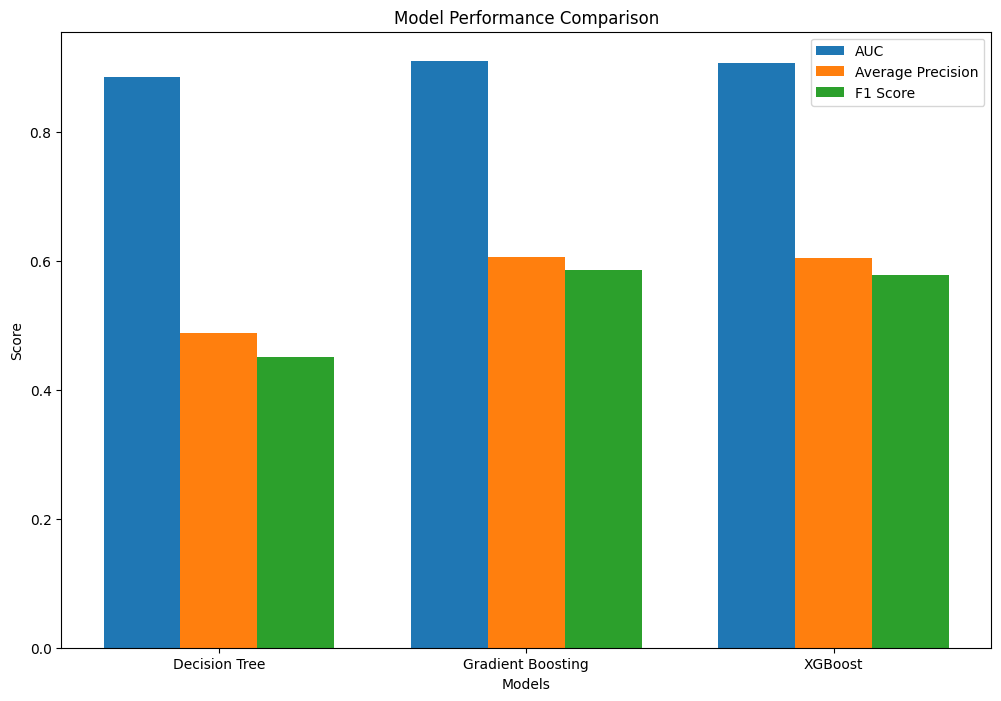

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Evaluates model performance with various metrics and plots
    """
    print(f"Evaluating {model_name}...")
    
    # Get predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Get probability predictions
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Classification report
    print(f"\n{model_name} Classification Report (Test):")
    print(classification_report(y_test, y_test_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png")
    plt.close()
    
    # ROC Curve
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
    roc_auc_train = auc(fpr_train, tpr_train)
    roc_auc_test = auc(fpr_test, tpr_test)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, color='blue', lw=2, label=f'Train ROC curve (area = {roc_auc_train:.3f})')
    plt.plot(fpr_test, tpr_test, color='green', lw=2, label=f'Test ROC curve (area = {roc_auc_test:.3f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_roc_curve.png")
    plt.close()
    
    # Precision-Recall Curve
    precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
    precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
    avg_precision_train = average_precision_score(y_train, y_train_proba)
    avg_precision_test = average_precision_score(y_test, y_test_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall_train, precision_train, lw=2, color='blue',
             label=f'Train P-R curve (AP = {avg_precision_train:.3f})')
    plt.plot(recall_test, precision_test, lw=2, color='green',
             label=f'Test P-R curve (AP = {avg_precision_test:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc="best")
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_pr_curve.png")
    plt.close()
    
    # Return metrics
    return {
        'accuracy_train': (y_train_pred == y_train).mean(),
        'accuracy_test': (y_test_pred == y_test).mean(),
        'auc_train': roc_auc_train,
        'auc_test': roc_auc_test,
        'avg_precision_train': avg_precision_train,
        'avg_precision_test': avg_precision_test,
        'f1_score_train': f1_score(y_train, y_train_pred),
        'f1_score_test': f1_score(y_test, y_test_pred)
    }

# Create the base preprocessing pipeline
preprocessing = Pipeline([
    ('dropper', DropNA(null_threshold=0.8)),  # Slightly more aggressive
    ('imputer', MissingValueImputer()),
    ('time_extractor', TimeFeatureExtractor()),
    ('user_behavior_extractor', UserBehaviorFeatureExtractor(use_multiple_ids=True)),
    ('cat_encoder', CatEncoding(threshold=3)),
    ('num_processor', NumericalProcessor(z_threshold=3.5))
])

# Prepare the data
print("Preparing data splits...")
X = train.drop('isFraud', axis=1)
y = train['isFraud']

# Small subset for faster experimentation (comment out for full dataset)
# X = X.sample(frac=0.1, random_state=42)
# y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set shape: {X_train.shape}, Positive class: {sum(y_train)}, ({sum(y_train)/len(y_train)*100:.2f}%)')
print(f'Test set shape: {X_test.shape}, Positive class: {sum(y_test)}, ({sum(y_test)/len(y_test)*100:.2f}%)')

# Process the datasets
print("Starting data preprocessing...")
import time
start_time = time.time()
X_train_preprocessed = preprocessing.fit_transform(X_train, y_train)
X_test_preprocessed = preprocessing.transform(X_test)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Data preprocessing completed in {elapsed_time:.2f} seconds")
print(f"Preprocessed shapes - Train: {X_train_preprocessed.shape}, Test: {X_test_preprocessed.shape}")

# Select top features
print("Performing feature selection...")
n_features = 150  # Reduced for faster training
feature_selector = SelectColumn(n_features=n_features)
X_train_selected = feature_selector.fit_transform(X_train_preprocessed, y_train)
X_test_selected = feature_selector.transform(X_test_preprocessed)

print(f"Selected {X_train_selected.shape[1]} features")
print(f"Feature selected shapes - Train: {X_train_selected.shape}, Test: {X_test_selected.shape}")

# Apply SMOTE for balancing the training set
print("Applying SMOTE to balance the training set...")
smote = SMOTE(random_state=42, sampling_strategy=0.5)  # Balanced but not fully 1:1
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

print(f"After SMOTE - X_train: {X_train_resampled.shape}, y_train: {len(y_train_resampled)}")
print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")
print(f"New fraud rate: {np.bincount(y_train_resampled)[1] / len(y_train_resampled) * 100:.2f}%")

# Train and evaluate Decision Tree
print("\n---------- Decision Tree Classifier ----------")
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)
dt_metrics = evaluate_model(dt_model, X_train_selected, X_test_selected, y_train, y_test, "Decision Tree")

# Train and evaluate Gradient Boosting
print("\n---------- Gradient Boosting Classifier ----------")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)
gb_metrics = evaluate_model(gb_model, X_train_selected, X_test_selected, y_train, y_test, "Gradient Boosting")

# Train and evaluate XGBoost for comparison
print("\n---------- XGBoost Classifier ----------")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)
xgb_metrics = evaluate_model(xgb_model, X_train_selected, X_test_selected, y_train, y_test, "XGBoost")

# Compare models
print("\n---------- Model Comparison ----------")
models = ["Decision Tree", "Gradient Boosting", "XGBoost"]
metrics = [dt_metrics, gb_metrics, xgb_metrics]

comparison_df = pd.DataFrame(metrics, index=models)
print(comparison_df)

# Plot model comparison
plt.figure(figsize=(12, 8))
test_metrics = ['auc_test', 'avg_precision_test', 'f1_score_test']
test_metrics_names = ['AUC', 'Average Precision', 'F1 Score']

x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(test_metrics):
    plt.bar(x + i*width, comparison_df[metric], width, label=test_metrics_names[i])

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width, models)
plt.legend()

In [5]:
!pip install imbalanced-learn==0.11.0 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 5.2 MB/s eta 0:00:0000:01


In [13]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

def log_model_to_mlflow(model, metrics, name, X_test):
    experiment_name = f"{name.replace(' ', '')}_Training"
    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name=f"{name}_Run") as run:
        # Log metrics
        for k, v in metrics.items():
            mlflow.log_metric(k, v)

        # Log model
        signature = infer_signature(X_test, model.predict(X_test))
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            signature=signature,
            input_example=X_test.iloc[:2]
        )

        # Register model
        mlflow.register_model(
            model_uri=f"runs:/{run.info.run_id}/model",
            name=f"{name.replace(' ', '')}_Model"
        )


In [14]:
log_model_to_mlflow(dt_model, dt_metrics, "Decision Tree", X_test_selected)



Successfully registered model 'DecisionTree_Model'.
2025/04/30 00:47:13 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DecisionTree_Model, version 1
Created version '1' of model 'DecisionTree_Model'.


🏃 View run Decision Tree_Run at: https://dagshub.com/ekvirika/FraudDerection.mlflow/#/experiments/6/runs/1594baf7aa0e4156a2289e08fa62ce42
🧪 View experiment at: https://dagshub.com/ekvirika/FraudDerection.mlflow/#/experiments/6
